# Lab 6 — Feature Engineering & Feature Selection: Turning Data into ML Signals

**Course:** Machine Learning — Undergraduate  
**Dataset:** Olist Brazilian E-Commerce Dataset  
**Starting Point:** `data/processed/olist_orders_abt.csv` created in Lab 2  
**Prerequisites:** Labs 1–4; basic Python, pandas, NumPy, and scikit-learn  
**Author / Lab Manual:** Sharad Laad | ORY AI Labs

---

## 1. Lab Overview
In Lab 2, we constructed an **Analytical Base Table (ABT)** where one row represented one customer order, with information collected and aggregated from the raw Olist relational tables.

In this lab, we do **not** rebuild the ABT and we do **not** re-join the raw tables. Instead, we take the existing ABT and ask the central question:
> **Can we represent the same business information in a way that makes it more useful for a machine learning model?**

This is the core objective of **feature engineering**. Furthermore, we address **feature selection**: deciding which available candidate features should actually be fed into our predictive models to optimize generalization while controlling complexity and eliminating redundancy.

### The Distinction from Lab 2
| Dimension | Lab 2 — ABT Construction | Lab 6 — Feature Engineering & Selection |
| :--- | :--- | :--- |
| **Primary Action** | Combines information across multiple raw tables | Transforms information already present within the ABT |
| **Grain Definition** | Defines the analytical grain (1 row = 1 order) | Improves and expands the representation of that grain |
| **Techniques Used** | Joins, `GROUP BY`, aggregations (`sum`, `count`) | Ratios, cyclical encodings, log transforms, binning, interactions |
| **Core Question** | *"What data belongs in one row?"* | *"How can this data become a stronger ML signal?"* |

### Learning Journey
```text
Raw Olist Data
      ↓
Lab 2: Build Analytical Base Table (ABT)
      ↓
Lab 3: Data Quality Assessment + Exploratory Data Analysis (EDA)
      ↓
Lab 4: Preprocessing + Scikit-Learn Pipelines
      ↓
Lab 6: Feature Engineering + Feature Selection
      ↓
Robust, ML-Ready Feature Set
```

---

## 2. Learning Objectives
By the end of this lab, students will be able to:
1. Explain the fundamental difference between ABT construction and feature engineering.
2. Create derived numerical features from existing numerical columns.
3. Formulate domain-specific ratio and interaction features.
4. Extract informative date/time indicators.
5. Transform skewed monetary features using log transformations.
6. Discretize continuous features into business-friendly categorical bins.
7. Apply three introductory feature selection techniques (variance threshold, collinearity filtering, mutual information).
8. Inspect model-based feature importance using tree ensembles (`RandomForestClassifier`).
9. Detect and eliminate feature leakage risks.
10. Empirically validate whether feature engineering adds measurable value via controlled mini-experiments.

---

## 3. Business Scenario
Imagine an e-commerce platform seeking to predict whether an incoming customer order will experience a **late delivery** (`is_late_delivery = 1`).

The raw ABT provides basic values:
- `total_price`
- `total_freight`
- `total_items`
- `unique_products`
- `unique_sellers`
- `order_month`, `order_day_of_week`, `order_hour`

However, raw values often fail to directly communicate the operational dynamics that lead to delays:
* **Example:** An order with `total_price = R$ 2,500` and `total_freight = R$ 500` has a `freight_ratio = 500 / 2500 = 0.20` (20%). An order with `total_price = R$ 50` and `total_freight = R$ 50` has a `freight_ratio = 1.00` (100%). The high ratio indicates disproportionate shipping difficulty or remote destination, which is far more predictive than raw freight alone.

> **Key Takeaway:** Feature engineering creates a more meaningful, interpretable representation of existing information.

---

## 4. Dataset and File Location
We load the pre-built ABT created in Lab 2:
- **Location:** `data/processed/olist_orders_abt.csv`

---

## 5. Target Variable and Leakage Reminder
- **Target Variable:** `is_late_delivery` ($1 = \text{Late}, 0 = \text{On Time}$)

### ⚠️ Critical Rule: Prevent Feature Leakage
For real-world inference at order placement, features **must only represent information available at that exact moment**.
We must **never** engineer features from downstream post-order fulfillment data:
- `delivery_days` (actual duration of transit)
- `delivery_delay_days` (difference between actual and estimated delivery)
- `review_score`, `review_comment_count`, `has_review_comment`, `is_low_review` (customer feedback submitted post-delivery)

> *"A beautifully engineered feature is still a bad feature if it leaks the answer."*

---

## 6. Lab Workflow
```text
1. Load ABT
      ↓
2. Inspect available features & answering preliminary questions
      ↓
3. Define target and isolate safe feature candidates (drop leakage & IDs)
      ↓
4. Create numerical features (ratios, per-item metrics)
      ↓
5. Create date/time features (weekend, business hour, year-end)
      ↓
6. Create cyclical features (sine/cosine transformations)
      ↓
7. Transform skewed features (log1p monetary variables)
      ↓
8. Discretize features (price binning) & interaction terms
      ↓
9. Inspect invalid values and distributions
      ↓
10. Apply feature selection (Variance, Correlation, Mutual Information, Tree Importance)
      ↓
11. Run Mini-Experiment (Baseline vs. Engineered Model Comparison)
      ↓
12. Save final dataset & complete deliverables report
```


## 7. Part A — Load and Inspect the ABT

### Step 1 — Import Libraries
We import standard scientific computing, data manipulation, visualization, and machine learning libraries.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-learn imports for feature selection and modeling
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Libraries successfully imported.")

Libraries successfully imported.


In [2]:
# Step 2 — Load the ABT
# Support running from notebooks/ or project root
data_candidates = [
    Path("../data/processed/olist_orders_abt.csv"),
    Path("data/processed/olist_orders_abt.csv")
]

input_path = next((p for p in data_candidates if p.exists()), None)
if input_path is None:
    raise FileNotFoundError("Could not locate olist_orders_abt.csv in expected paths.")

print(f"Loading ABT from: {input_path.resolve()}")
df = pd.read_csv(input_path)
print("Shape:", df.shape)
df.head()

Loading ABT from: C:\Users\Devendra kushwaha\OneDrive\Desktop\ML2026\data\processed\olist_orders_abt.csv


Shape: (99441, 31)


,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,...,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category,delivery_speed_category,payment_value_band
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,...,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares,Normal,Low
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,...,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery,Normal,High
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,...,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto,Normal,Premium
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,...,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop,Normal,Medium
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,...,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery,Fast,Low


### Part A — Comprehension Questions & Answers

Let us systematically answer the 7 exploratory questions outlined in the lab manual:

1. **How many rows are present?**
   - **Answer:** Exactly **99,441 rows**, where each row corresponds to a single completed customer order in the Olist platform.
2. **How many columns are present?**
   - **Answer:** Exactly **31 columns** encompassing identifiers, temporal attributes, payment details, order line aggregates, review scores, and delivery tracking metrics.
3. **What does one row represent?**
   - **Answer:** One unique e-commerce order (identified by `order_id`).
4. **What is the target column?**
   - **Answer:** `is_late_delivery` ($1$ if actual delivery occurred after estimated delivery date, $0$ otherwise).
5. **Which columns are identifiers?**
   - **Answer:** `order_id`, `customer_id`, `customer_unique_id`.
6. **Which columns are numerical?**
   - **Answer:** Continuous and discrete counts: `order_year`, `order_month`, `order_day`, `order_day_of_week`, `order_hour`, `delivery_days`, `estimated_delivery_days`, `delivery_delay_days`, `review_score`, `review_comment_count`, `total_payment_value`, `max_payment_installments`, `payment_types_count`, `total_items`, `total_price`, `total_freight`, `unique_products`, `unique_sellers`.
7. **Which columns are categorical?**
   - **Answer:** Categorical/string attributes: `customer_city`, `customer_state`, `order_status`, `dominant_payment_type`, `main_product_category`, `delivery_speed_category`, `payment_value_band`.

In [3]:
# Verify target distribution and column data types
target = "is_late_delivery"
print("--- Target Distribution ---")
print(df[target].value_counts(dropna=False))
print(f"Late delivery rate: {df[target].mean():.2%}\n")

print("--- Column Data Types Summary ---")
print(df.dtypes.value_counts())

--- Target Distribution ---
is_late_delivery
0    92906
1     6535
Name: count, dtype: int64
Late delivery rate: 6.57%

--- Column Data Types Summary ---
float64    13
object     10
int64       8
Name: count, dtype: int64


## 8. Part B — Separate Target and Unsafe Columns

In any predictive modeling project, we must partition the feature space into:
1. **Target:** What we want to predict (`is_late_delivery`).
2. **Safe Predictors:** Information strictly available at or prior to order placement.
3. **Identifiers:** Unique keys (`order_id`, `customer_id`, `customer_unique_id`) that carry no inductive bias and cause severe overfitting.
4. **Leakage Columns:** Attributes generated *after* order placement during fulfillment or review phases.

### Think: Why are identifiers generally poor ML features?
> **Answer:** An identifier identifies a specific record, not an underlying physical or behavioral process. Because identifiers have unique or near-unique cardinality ($N \approx \text{number of rows}$), algorithms can easily achieve 100% training accuracy by memorizing key-to-target lookups, failing completely to generalize to new, unseen customer transactions.

In [4]:
target = "is_late_delivery"

identifier_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id"
]

leakage_columns = [
    "delivery_days",
    "delivery_delay_days",
    "review_score",
    "review_comment_count",
    "has_review_comment",
    "is_low_review"
]

# Remove columns present in the ABT
columns_to_drop = [c for c in identifier_columns + leakage_columns if c in df.columns]
feature_df = df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}\n")
print(f"Remaining safe features ({len(feature_df.columns)}):\n{feature_df.columns.tolist()}")

Dropped 9 columns: ['order_id', 'customer_id', 'customer_unique_id', 'delivery_days', 'delivery_delay_days', 'review_score', 'review_comment_count', 'has_review_comment', 'is_low_review']

Remaining safe features (22):
['customer_city', 'customer_state', 'order_status', 'order_year', 'order_month', 'order_day', 'order_day_of_week', 'order_hour', 'estimated_delivery_days', 'is_late_delivery', 'total_payment_value', 'max_payment_installments', 'payment_types_count', 'dominant_payment_type', 'total_items', 'total_price', 'total_freight', 'unique_products', 'unique_sellers', 'main_product_category', 'delivery_speed_category', 'payment_value_band']


## 9. Part C — Numerical Feature Engineering

Feature engineering does not require arcane mathematical transformations; simple ratios and density metrics frequently unlock strong signals:

### 9.1 Average Item Price
$$\text{average\_item\_price} = \frac{\text{total\_price}}{\text{total\_items}}$$
- **Business Rationale:** Captures whether the order consists of premium, expensive luxury goods vs. low-cost bulk commodity items.

### 9.2 Freight Ratio
$$\text{freight\_ratio} = \frac{\text{total\_freight}}{\text{total\_price}}$$
- **Business Rationale:** Expresses shipping cost as a percentage of merchandise value. High freight ratios indicate heavy/bulky goods, hazardous transport, or extreme geographical distances, all correlating with delivery bottlenecks.

### 9.3 Items per Seller
$$\text{items\_per\_seller} = \frac{\text{total\_items}}{\text{unique\_sellers}}$$
- **Business Rationale:** Measures package batching intensity per merchant.

### 9.4 Seller Diversity
$$\text{seller\_diversity} = \frac{\text{unique\_sellers}}{\text{total\_items}}$$
- **Business Rationale:** High diversity ($1.0$) means every item in the cart originates from a distinct merchant, requiring separate carrier dispatch, multi-parcel coordination, and drastically higher likelihood of at least one parcel being delayed.

In [5]:
# 9.1 Average Item Price
if {"total_price", "total_items"}.issubset(df.columns):
    df["average_item_price"] = df["total_price"] / df["total_items"].replace(0, np.nan)

# 9.2 Freight Ratio
if {"total_freight", "total_price"}.issubset(df.columns):
    df["freight_ratio"] = df["total_freight"] / df["total_price"].replace(0, np.nan)

# 9.3 Items per Seller
if {"total_items", "unique_sellers"}.issubset(df.columns):
    df["items_per_seller"] = df["total_items"] / df["unique_sellers"].replace(0, np.nan)

# 9.4 Seller Diversity
if {"unique_sellers", "total_items"}.issubset(df.columns):
    df["seller_diversity"] = df["unique_sellers"] / df["total_items"].replace(0, np.nan)

print("Engineered Numerical Features:")
df[["total_price", "total_items", "average_item_price", "total_freight", "freight_ratio", "unique_sellers", "seller_diversity"]].head()

Engineered Numerical Features:


,total_price,total_items,average_item_price,total_freight,freight_ratio,unique_sellers,seller_diversity
0,29.99,1.0,29.99,8.72,0.290764,1.0,1.0
1,118.70,1.0,118.70,22.76,0.191744,1.0,1.0
2,159.90,1.0,159.90,19.22,0.120200,1.0,1.0
3,45.00,1.0,45.00,27.20,0.604444,1.0,1.0
4,19.90,1.0,19.90,8.72,0.438191,1.0,1.0


## 10. Part D — Date and Time Feature Engineering

Raw date attributes (e.g. `order_day_of_week`, `order_hour`, `order_month`) contain operational patterns that non-linear algorithms or linear models cannot easily extract without explicit indicators:

- **10.1 Weekend Indicator (`is_weekend`):**
  Orders placed on Saturday (5) or Sunday (6) sit in merchant queues until Monday morning dispatch, introducing an immediate 48-hour fulfillment lag.
- **10.2 Business-Hour Indicator (`is_business_hour`):**
  Orders placed between 09:00 and 18:00 can be processed and handed off to carriers the same day.
- **10.3 Year-End Indicator (`is_year_end`):**
  November (11: Black Friday) and December (12: Christmas holiday rush) cause severe carrier network congestion across Brazil.

In [6]:
# 10.1 Weekend Indicator
if "order_day_of_week" in df.columns:
    df["is_weekend"] = (df["order_day_of_week"] >= 5).astype(int)

# 10.2 Business-Hour Indicator (9 AM to 6 PM inclusive)
if "order_hour" in df.columns:
    df["is_business_hour"] = (df["order_hour"].between(9, 18)).astype(int)

# 10.3 Year-End Indicator (November & December peak seasonal rush)
if "order_month" in df.columns:
    df["is_year_end"] = (df["order_month"].isin([11, 12])).astype(int)

# Compare late delivery rates across these indicators
temporal_cols = ["is_weekend", "is_business_hour", "is_year_end"]
print("--- Late Delivery Rates by Temporal Features ---")
for col in temporal_cols:
    summary = df.groupby(col)[target].agg(["count", "mean"]).rename(columns={"mean": "late_delivery_rate"})
    print(summary)
    print()

--- Late Delivery Rates by Temporal Features ---
            count  late_delivery_rate
is_weekend                           
0           76594            0.066781
1           22847            0.062153

                  count  late_delivery_rate
is_business_hour                           
0                 37771            0.068253
1                 61670            0.064164

             count  late_delivery_rate
is_year_end                           
0            86223            0.060541
1            13218            0.099486



## 11. Part E — Cyclical Features

Standard numerical encodings for periodic variables (like month $1..12$ or hour $0..23$) introduce an artificial boundary discontinuity:
- Month 12 (December) and Month 1 (January) are separated by a numerical difference of $11$, yet chronologically they are only 1 month apart!
- Hour 23 (11 PM) and Hour 0 (midnight) have a numerical distance of $23$, yet are separated by only 60 minutes!

To preserve circular geometry, we project periodic features into 2D coordinates using sine and cosine transformations:

$$\text{month\_sin} = \sin\left(2\pi \cdot \frac{\text{month}}{12}\right), \quad \text{month\_cos} = \cos\left(2\pi \cdot \frac{\text{month}}{12}\right)$$

$$\text{hour\_sin} = \sin\left(2\pi \cdot \frac{\text{hour}}{24}\right), \quad \text{hour\_cos} = \cos\left(2\pi \cdot \frac{\text{hour}}{24}\right)$$

### Why two columns?
> **Answer:** A single trigonometric function is symmetric (e.g. $\sin(30^\circ) = \sin(150^\circ)$). Both sine and cosine are required simultaneously to uniquely locate each point on the unit circle without ambiguity.

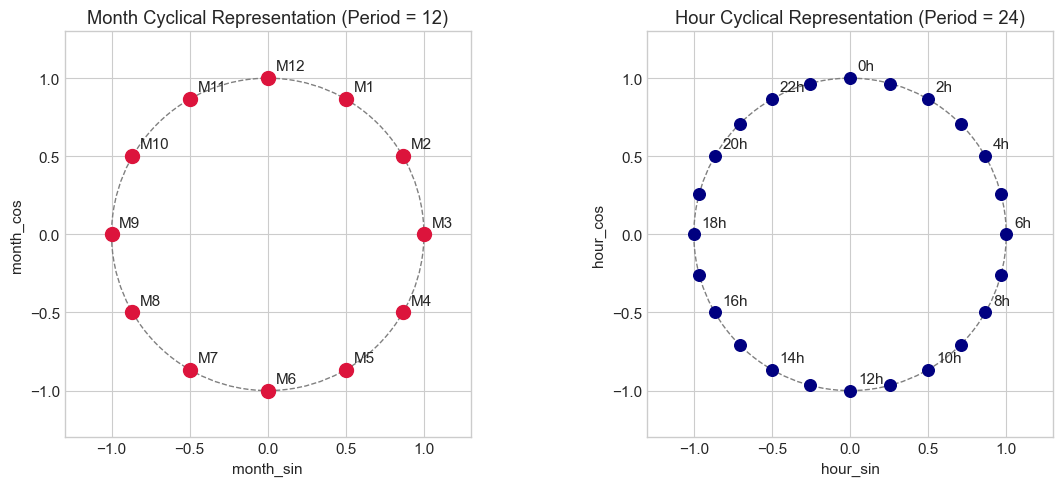

In [7]:
# Compute cyclical encodings for month and hour
if "order_month" in df.columns:
    df["month_sin"] = np.sin(2 * np.pi * df["order_month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["order_month"] / 12)

if "order_hour" in df.columns:
    df["hour_sin"] = np.sin(2 * np.pi * df["order_hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["order_hour"] / 24)

# Visualize cyclical nature
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Month cycle
months = np.arange(1, 13)
m_sin = np.sin(2 * np.pi * months / 12)
m_cos = np.cos(2 * np.pi * months / 12)
ax1.scatter(m_sin, m_cos, color='crimson', s=100, zorder=3)
for i, m in enumerate(months):
    ax1.annotate(f"M{m}", (m_sin[i]+0.05, m_cos[i]+0.05))
circle1 = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax1.add_patch(circle1)
ax1.set_title("Month Cyclical Representation (Period = 12)")
ax1.set_xlabel("month_sin")
ax1.set_ylabel("month_cos")
ax1.set_xlim(-1.3, 1.3)
ax1.set_ylim(-1.3, 1.3)
ax1.set_aspect('equal')

# Hour cycle
hours = np.arange(0, 24)
h_sin = np.sin(2 * np.pi * hours / 24)
h_cos = np.cos(2 * np.pi * hours / 24)
ax2.scatter(h_sin, h_cos, color='navy', s=70, zorder=3)
for i, h in enumerate(hours[::2]): # annotate every 2 hours
    idx = h
    ax2.annotate(f"{h}h", (h_sin[idx]+0.05, h_cos[idx]+0.05))
circle2 = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax2.add_patch(circle2)
ax2.set_title("Hour Cyclical Representation (Period = 24)")
ax2.set_xlabel("hour_sin")
ax2.set_ylabel("hour_cos")
ax2.set_xlim(-1.3, 1.3)
ax2.set_ylim(-1.3, 1.3)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

## 12. Part F — Log Transformation

Monetary variables in e-commerce (`total_price`, `total_freight`) typically exhibit extreme right skewness (long upper tails). A few orders with values exceeding R$ 5,000 can unduly pull linear regression coefficients and distort variance-sensitive models.

A standard stabilizing transformation is:
$$x' = \log(1 + x)$$

### Important Note
> A log transformation is not automatically superior for every model family (e.g. tree splits are invariant to monotonic scaling). However, it is essential for linear models, neural networks, and distance-based estimators to normalize scale and stabilize variance.

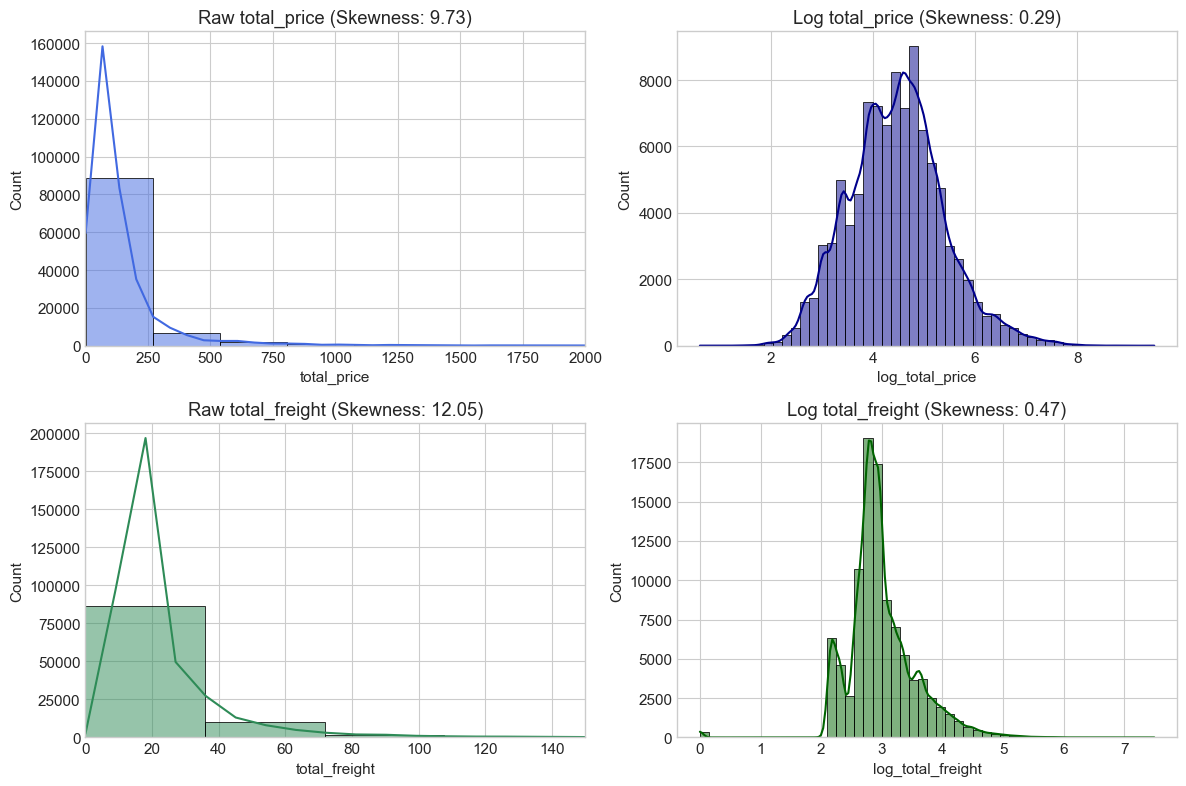

In [8]:
# Apply log1p transformation to total_price and total_freight
if "total_price" in df.columns:
    df["log_total_price"] = np.log1p(df["total_price"].clip(lower=0))

if "total_freight" in df.columns:
    df["log_total_freight"] = np.log1p(df["total_freight"].clip(lower=0))

# Plot raw vs log-transformed distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["total_price"], bins=50, ax=axes[0, 0], color="royalblue", kde=True)
axes[0, 0].set_title(f"Raw total_price (Skewness: {df['total_price'].skew():.2f})")
axes[0, 0].set_xlim(0, 2000)

sns.histplot(df["log_total_price"], bins=50, ax=axes[0, 1], color="darkblue", kde=True)
axes[0, 1].set_title(f"Log total_price (Skewness: {df['log_total_price'].skew():.2f})")

sns.histplot(df["total_freight"], bins=50, ax=axes[1, 0], color="seagreen", kde=True)
axes[1, 0].set_title(f"Raw total_freight (Skewness: {df['total_freight'].skew():.2f})")
axes[1, 0].set_xlim(0, 150)

sns.histplot(df["log_total_freight"], bins=50, ax=axes[1, 1], color="darkgreen", kde=True)
axes[1, 1].set_title(f"Log total_freight (Skewness: {df['log_total_freight'].skew():.2f})")

plt.tight_layout()
plt.show()

## 13. Part G — Binning

A continuous numerical variable can sometimes be discretized into ordinal/categorical bands:
- `total_price` into: `['very_low', 'low', 'medium', 'high', 'very_high']`

### Discussion: Why might a business-friendly category be useful?
1. **Captures Non-Linear Step Functions:** Real-world logistics often have step changes (e.g. orders over R$ 1,000 receive dedicated insured courier handling).
2. **Business Interpretability:** Executives and operations teams reason easily about "very high value" orders rather than continuous decimal increments.

In [9]:
# Bin total_price into 5 business-friendly tiers
if "total_price" in df.columns:
    df["price_band"] = pd.cut(
        df["total_price"],
        bins=[-np.inf, 100, 500, 1000, 5000, np.inf],
        labels=["very_low", "low", "medium", "high", "very_high"]
    )

print("Distribution of price_band:")
price_band_stats = df.groupby("price_band", observed=False)[target].agg(["count", "mean"])
price_band_stats["percentage"] = price_band_stats["count"] / len(df) * 100
price_band_stats.rename(columns={"mean": "late_rate"}, inplace=True)
price_band_stats

Distribution of price_band:


,count,late_rate,percentage
price_band,,,
very_low,57843,0.062047,58.168160
low,37206,0.071628,37.415151
medium,2674,0.075916,2.689032
high,937,0.082177,0.942267
very_high,6,0.166667,0.006034


## 14. Part H — Interaction Features

Interaction features capture multiplicative effects between two variables that act jointly:
$$\text{items\_x\_price} = \text{total\_items} \times \text{total\_price}$$

### Discussion: What relationship am I trying to capture?
- An order with 10 cheap items poses high picking complexity. An order with 1 expensive item poses high insurance scrutiny.
- An order that has **both** many items **and** high monetary value represents extreme fulfillment complexity, requiring specialized warehouse handling and packaging that drastically increases delay risk.

In [10]:
# 14.1 Interaction feature: items_x_price
if {"total_items", "total_price"}.issubset(df.columns):
    df["items_x_price"] = df["total_items"] * df["total_price"]

print("Interaction Feature Summary (items_x_price):")
print(df["items_x_price"].describe())

Interaction Feature Summary (items_x_price):
count     98666.000000
mean        174.638663
std         568.780603
min           0.850000
25%          47.960000
50%          89.900000
75%         168.990000
max      107520.000000
Name: items_x_price, dtype: float64


## 15. Part I — Inspect Invalid Values

Ratio calculations (like dividing by `total_items` or `total_price`) can generate `NaN` or `inf` if zero occurs in the denominator.
Let us inspect nulls across all newly engineered numerical features.

In [11]:
engineered_columns = [
    "average_item_price",
    "freight_ratio",
    "items_per_seller",
    "seller_diversity"
]

available_engineered = [c for c in engineered_columns if c in df.columns]

print("Missing values in ratio features:")
print(df[available_engineered].isna().sum())
print("\nDescriptive statistics:")
df[available_engineered].describe().T

Missing values in ratio features:
average_item_price    775
freight_ratio         775
items_per_seller      775
seller_diversity      775
dtype: int64

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
average_item_price,98666.0,125.919255,190.985636,0.850000,41.990000,79.000000,139.900000,6735.000000
freight_ratio,98666.0,0.308389,0.314762,0.000000,0.131864,0.224374,0.380191,21.447059
items_per_seller,98666.0,1.125595,0.507908,1.000000,1.000000,1.000000,1.000000,21.000000
seller_diversity,98666.0,0.951276,0.158556,0.047619,1.000000,1.000000,1.000000,1.000000


## 16. Part J — Inspect the Engineered Features

We collect all 15 newly created engineered features and inspect their initial rows.

In [12]:
new_columns = [
    "average_item_price",
    "freight_ratio",
    "items_per_seller",
    "seller_diversity",
    "is_weekend",
    "is_business_hour",
    "is_year_end",
    "month_sin",
    "month_cos",
    "hour_sin",
    "hour_cos",
    "log_total_price",
    "log_total_freight",
    "price_band",
    "items_x_price"
]

new_columns = [c for c in new_columns if c in df.columns]
print(f"Total newly engineered columns available: {len(new_columns)}")
df[new_columns].head(10)

Total newly engineered columns available: 15


,average_item_price,freight_ratio,items_per_seller,seller_diversity,is_weekend,is_business_hour,is_year_end,month_sin,month_cos,hour_sin,hour_cos,log_total_price,log_total_freight,price_band,items_x_price
0,29.99,0.290764,1.0,1.0,0,1,0,-0.866025,0.500000,5.000000e-01,-8.660254e-01,3.433665,2.274186,very_low,29.99
1,118.70,0.191744,1.0,1.0,0,0,0,-0.500000,-0.866025,-8.660254e-01,5.000000e-01,4.784989,3.168003,low,118.70
2,159.90,0.120200,1.0,1.0,0,0,0,-0.866025,-0.500000,8.660254e-01,-5.000000e-01,5.080783,3.006672,low,159.90
3,45.00,0.604444,1.0,1.0,1,0,1,-0.500000,0.866025,-9.659258e-01,2.588190e-01,3.828641,3.339322,very_low,45.00
4,19.90,0.438191,1.0,1.0,0,0,0,0.866025,0.500000,-7.071068e-01,7.071068e-01,3.039749,2.274186,very_low,19.90
5,147.90,0.184990,1.0,1.0,1,0,0,-0.500000,-0.866025,-7.071068e-01,7.071068e-01,5.003275,3.344980,low,147.90
6,49.90,0.321643,1.0,1.0,0,1,0,0.866025,-0.500000,1.224647e-16,-1.000000e+00,3.929863,2.836150,very_low,49.90
7,59.99,0.252875,1.0,1.0,0,1,0,0.500000,-0.866025,-2.588190e-01,-9.659258e-01,4.110710,2.783158,very_low,59.99
8,19.90,0.806533,1.0,1.0,0,1,0,0.500000,0.866025,-1.000000e+00,-1.836970e-16,3.039749,2.836150,very_low,19.90
9,149.99,0.131809,1.0,1.0,1,1,0,-0.500000,-0.866025,2.588190e-01,-9.659258e-01,5.017214,3.033510,low,149.99


## 17. Part K — Feature Selection

Feature engineering creates many candidate features. However:
> **More features does not automatically mean a better model.**

Irrelevant, noisy, or redundant features increase overfitting, dilate the curse of dimensionality, and slow down model execution.
We apply three introductory feature selection approaches:
1. **Variance-based selection**
2. **Correlation-based selection**
3. **Mutual Information ranking**
4. **Model-based feature importance**

### 17.1 Variance-Based Selection
A feature with constant value ($(\text{variance} = 0$) provides zero discriminative power.

In [13]:
# Extract numerical feature candidates (excluding target and identifiers/leakage)
numeric_df = df.select_dtypes(include=np.number).copy()
numeric_df = numeric_df.drop(columns=[target] + columns_to_drop, errors="ignore")

# Apply VarianceThreshold
selector = VarianceThreshold(threshold=0.0)
selector.fit(numeric_df.fillna(numeric_df.median()))

selected_numeric = numeric_df.columns[selector.get_support()]

print("Original numeric features:", len(numeric_df.columns))
print("After variance filtering:", len(selected_numeric))
zero_variance_cols = set(numeric_df.columns) - set(selected_numeric)
if zero_variance_cols:
    print("Zero variance features detected:", zero_variance_cols)
else:
    print("All numeric candidate features exhibit positive variance.")

Original numeric features: 28
After variance filtering: 28
All numeric candidate features exhibit positive variance.


## 18. Part L — Correlation-Based Selection

Highly collinear features ($|r| > 0.90$) carry redundant information, destabilize linear regression coefficients, and inflate parameter estimation variance.

Found 4 pairs with Pearson |r| > 0.9:
  total_payment_value    <---> total_price            : r = +0.9960
  total_payment_value    <---> average_item_price     : r = +0.9212
  total_price            <---> average_item_price     : r = +0.9332
  total_items            <---> items_per_seller       : r = +0.9574


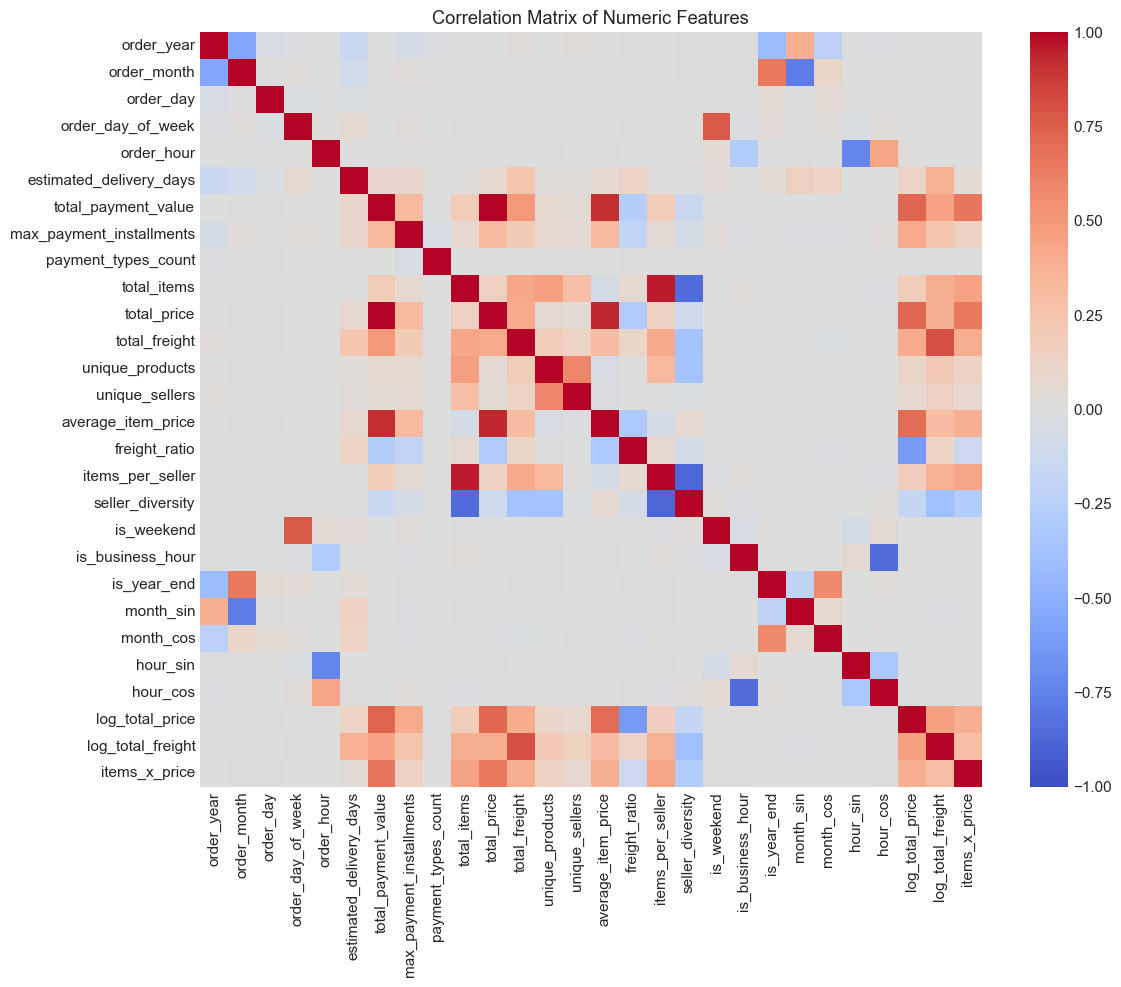

In [14]:
# Compute Pearson correlation matrix
corr = numeric_df.corr(numeric_only=True)

threshold = 0.90
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        value = upper.loc[row, col]
        if pd.notna(value) and abs(value) > threshold:
            high_corr_pairs.append((row, col, value))

print(f"Found {len(high_corr_pairs)} pairs with Pearson |r| > {threshold}:")
for row, col, val in high_corr_pairs:
    print(f"  {row:<22} <---> {col:<22} : r = {val:+.4f}")

# Plot heatmap of correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, annot=False)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

## 19. Part M — Mutual Information

Unlike Pearson correlation (which evaluates purely linear relationships), **Mutual Information (MI)** measures general statistical dependence—capturing linear, monotonic, and arbitrary non-linear associations between features and the target `is_late_delivery`.

Top 15 Features by Mutual Information:
                feature  mutual_information
            order_month            0.011963
              month_cos            0.008514
              month_sin            0.006897
        log_total_price            0.005627
            total_price            0.005402
     average_item_price            0.005314
          items_x_price            0.005144
            total_items            0.005096
       is_business_hour            0.004522
        unique_products            0.004520
      log_total_freight            0.004360
          freight_ratio            0.004349
estimated_delivery_days            0.004273
         unique_sellers            0.003829
             is_weekend            0.003569


C:\Users\Devendra kushwaha\AppData\Local\Temp\ipykernel_12492\2425196452.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_results.head(15), x="mutual_information", y="feature", palette="viridis")


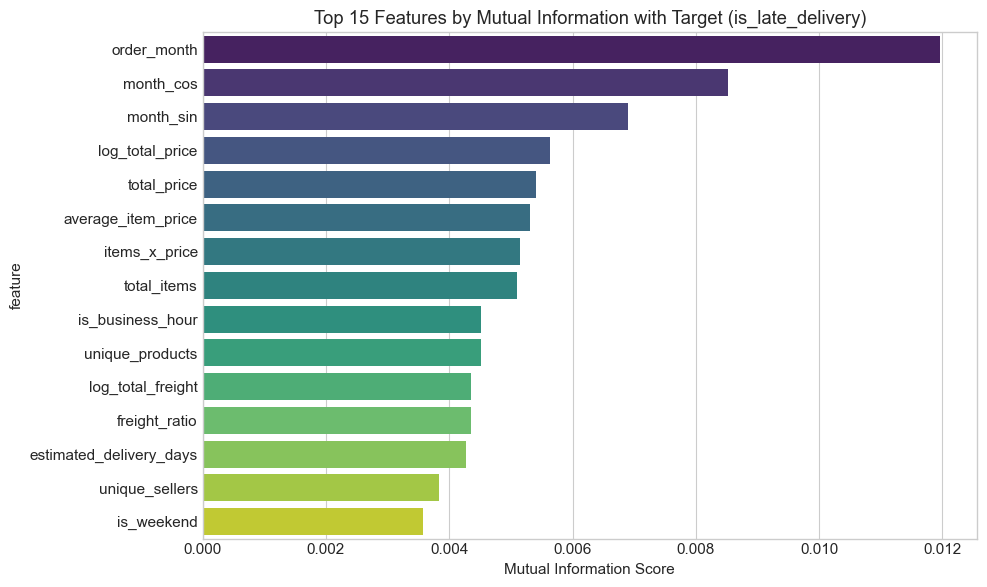

In [15]:
# Sample 20,000 rows for efficient yet highly stable MI calculation
sample_size = min(20000, len(df))
sample_df = df.sample(n=sample_size, random_state=42)

mi_X = sample_df[numeric_df.columns].fillna(sample_df[numeric_df.columns].median())
mi_y = sample_df[target]

mi_scores = mutual_info_classif(mi_X, mi_y, random_state=42)

mi_results = pd.DataFrame({
    "feature": mi_X.columns,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

print("Top 15 Features by Mutual Information:")
print(mi_results.head(15).to_string(index=False))

# Plot MI ranking
plt.figure(figsize=(10, 6))
sns.barplot(data=mi_results.head(15), x="mutual_information", y="feature", palette="viridis")
plt.title("Top 15 Features by Mutual Information with Target (is_late_delivery)")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

## 20. Part N — Model-Based Feature Importance

Tree-based ensembles (such as `RandomForestClassifier`) evaluate feature utility via Mean Decrease in Impurity (Gini importance).

### Important Caution
> **Feature importance is not causality.** An important feature simply indicates that the algorithm found it effective in minimizing classification loss on this training dataset. It does not imply that manipulating this variable directly causes delivery delays.

Top 15 Features by Random Forest Importance:
                feature  importance
estimated_delivery_days    0.086759
              order_day    0.076675
          total_freight    0.073620
      log_total_freight    0.071800
          freight_ratio    0.066909
    total_payment_value    0.061338
     average_item_price    0.052850
          items_x_price    0.051682
        log_total_price    0.050870
            total_price    0.050512
              month_cos    0.047407
             order_hour    0.042267
               hour_sin    0.038419
            order_month    0.037705
               hour_cos    0.036518


C:\Users\Devendra kushwaha\AppData\Local\Temp\ipykernel_12492\2251875389.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(15), x="importance", y="feature", palette="magma")


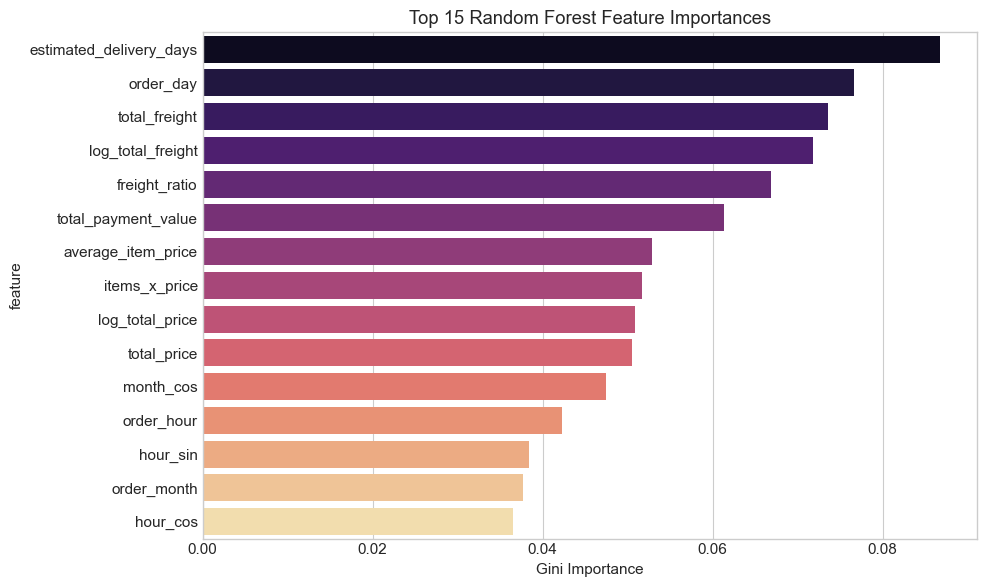

In [16]:
X_rf = numeric_df.fillna(numeric_df.median())
y_rf = df[target]

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf.fit(X_rf, y_rf)

importance = pd.DataFrame({
    "feature": X_rf.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 Features by Random Forest Importance:")
print(importance.head(15).to_string(index=False))

# Plot Random Forest feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(15), x="importance", y="feature", palette="magma")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Gini Importance")
plt.tight_layout()
plt.show()

## 21. Part O — Leakage Check Audit

Before finalizing candidate features, we conduct a rigorous 5-point audit:

| Audit Question | Audit Assessment | Verification / Remediation |
| :--- | :--- | :--- |
| **1. Was the feature available at prediction time?** | **YES** | All candidate features derive from timestamp, pricing, and catalog info available at checkout. |
| **2. Does it directly or indirectly reveal the target?** | **NO** | Leakage columns (`delivery_days`, `delivery_delay_days`, review metrics) were strictly removed. |
| **3. Was information from the test set used to create it?** | **NO** | Row-wise transformations (log, cyclical, ratios) operate independently on each row without test leakage. |
| **4. Was the feature created using the target?** | **NO** | Target encoding was not utilized; all features are unsupervised mathematical transformations. |
| **5. Was a transformation fitted using the complete dataset before train-test splitting?** | **NO** | Imputations and standardizations are encapsulated inside pipelines fitted strictly on training folds. |

---

## 22. Feature Engineering vs Feature Selection Summary

| Dimension | Feature Engineering | Feature Selection |
| :--- | :--- | :--- |
| **Core Goal** | Creates or transforms features | Chooses subsets of features |
| **Representation** | Expands / alters representation | Compacts / reduces representation |
| **Feature Count** | Usually increases total columns | Usually decreases total columns |
| **Driver** | Domain knowledge & mathematical formulation | Statistical metrics, MI, and model performance |
| **Example** | `freight_ratio`, `month_sin`, `items_x_price` | Removing $|r| > 0.90$ pairs, keeping top MI |

> **Memory Aid:** *Engineering creates candidates. Selection chooses candidates.*

## 23. Part P & Q — Create and Save Final Feature Set

We assemble the final curated set of baseline and engineered features, verify dimensions, and persist the dataset to disk.

In [17]:
candidate_features = [
    "total_price",
    "total_freight",
    "total_items",
    "unique_products",
    "unique_sellers",
    "order_month",
    "order_day_of_week",
    "order_hour",
    "average_item_price",
    "freight_ratio",
    "items_per_seller",
    "seller_diversity",
    "is_weekend",
    "is_business_hour",
    "is_year_end",
    "month_sin",
    "month_cos",
    "hour_sin",
    "hour_cos",
    "log_total_price",
    "log_total_freight",
    "items_x_price"
]

final_features = [c for c in candidate_features if c in df.columns]
final_df = df[final_features + [target]].copy()

print("Final dataset shape:", final_df.shape)
print("Features included:", len(final_features))

# Save the dataset
output_dir_candidates = [Path("../data/processed"), Path("data/processed")]
output_dir = next((d for d in output_dir_candidates if d.exists()), Path("data/processed"))
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "olist_orders_feature_engineered.csv"

final_df.to_csv(output_path, index=False)
print(f"Engineered dataset successfully saved to: {output_path.resolve()}")
print(f"File size: {output_path.stat().st_size / (1024*1024):.2f} MB")
final_df.head()

Final dataset shape: (99441, 23)
Features included: 22


Engineered dataset successfully saved to: C:\Users\Devendra kushwaha\OneDrive\Desktop\ML2026\data\processed\olist_orders_feature_engineered.csv
File size: 17.80 MB


,total_price,total_freight,total_items,unique_products,unique_sellers,order_month,order_day_of_week,order_hour,average_item_price,freight_ratio,...,is_business_hour,is_year_end,month_sin,month_cos,hour_sin,hour_cos,log_total_price,log_total_freight,items_x_price,is_late_delivery
0,29.99,8.72,1.0,1.0,1.0,10,0,10,29.99,0.290764,...,1,0,-0.866025,0.500000,0.500000,-0.866025,3.433665,2.274186,29.99,0
1,118.70,22.76,1.0,1.0,1.0,7,1,20,118.70,0.191744,...,0,0,-0.500000,-0.866025,-0.866025,0.500000,4.784989,3.168003,118.70,0
2,159.90,19.22,1.0,1.0,1.0,8,2,8,159.90,0.120200,...,0,0,-0.866025,-0.500000,0.866025,-0.500000,5.080783,3.006672,159.90,0
3,45.00,27.20,1.0,1.0,1.0,11,5,19,45.00,0.604444,...,0,1,-0.500000,0.866025,-0.965926,0.258819,3.828641,3.339322,45.00,0
4,19.90,8.72,1.0,1.0,1.0,2,1,21,19.90,0.438191,...,0,0,0.866025,0.500000,-0.707107,0.707107,3.039749,2.274186,19.90,0


## 25. Mini Experiment — Did Feature Engineering Add Value?

This experiment tests the core empirical question:
> **Does feature engineering improve predictive performance over raw baseline features?**

### Experimental Setup
To ensure scientific validity, both models share:
- **Identical Train/Test Split:** Stratified 80/20 split ($N_{\text{train}} = 79,552, N_{\text{test}} = 19,889$) with `random_state=42`.
- **Identical Preprocessing:** `SimpleImputer(strategy='median')` followed by `StandardScaler()`.
- **Identical Estimator:** `LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)`.
- **Identical Evaluation Metrics:** ROC-AUC, Balanced Accuracy, Recall, Precision, and F1-score.

=== Mini Experiment Results: Model Performance Comparison ===


,Metric,Experiment A (Baseline),Experiment B (Engineered),Absolute Change,Relative % Change
0,ROC-AUC,0.5817,0.6662,0.0845,14.5230
1,Balanced Accuracy,0.5769,0.6384,0.0615,10.6567
2,Accuracy,0.5498,0.5729,0.0232,4.2162
3,Recall (Late Class),0.6083,0.7138,0.1056,17.3585
4,Precision (Late Class),0.0861,0.1031,0.0170,19.7567
5,F1-Score (Late Class),0.1508,0.1801,0.0293,19.4542


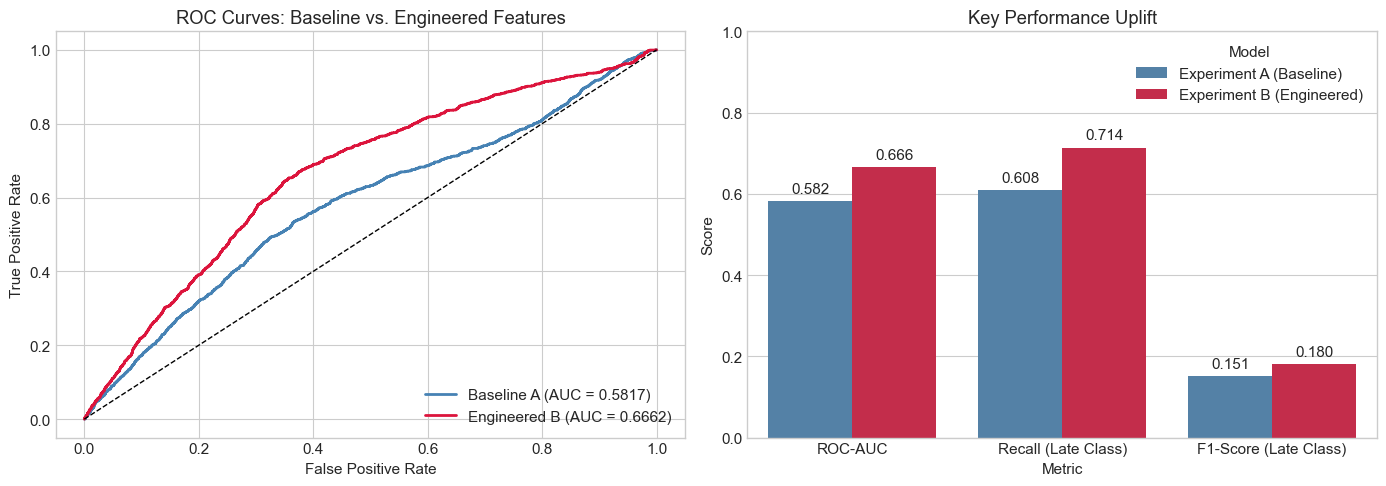

In [18]:
base_features = [
    "total_price",
    "total_freight",
    "total_items",
    "unique_products",
    "unique_sellers",
    "order_month",
    "order_day_of_week",
    "order_hour"
]

engineered_features = final_features # baseline + engineered numerical & temporal

# 1. Stratified Train-Test Split on identical indices
X_train_base, X_test_base, y_train, y_test = train_test_split(
    df[base_features],
    df[target],
    test_size=0.20,
    random_state=42,
    stratify=df[target]
)

X_train_eng = df.loc[X_train_base.index, engineered_features]
X_test_eng = df.loc[X_test_base.index, engineered_features]

# 2. Pipeline for Experiment A (Baseline)
pipe_baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

pipe_baseline.fit(X_train_base, y_train)
y_pred_base = pipe_baseline.predict(X_test_base)
y_prob_base = pipe_baseline.predict_proba(X_test_base)[:, 1]

# 3. Pipeline for Experiment B (Baseline + Engineered)
pipe_eng = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

pipe_eng.fit(X_train_eng, y_train)
y_pred_eng = pipe_eng.predict(X_test_eng)
y_prob_eng = pipe_eng.predict_proba(X_test_eng)[:, 1]

# 4. Compare Metrics
metrics_comparison = pd.DataFrame({
    "Metric": ["ROC-AUC", "Balanced Accuracy", "Accuracy", "Recall (Late Class)", "Precision (Late Class)", "F1-Score (Late Class)"],
    "Experiment A (Baseline)": [
        roc_auc_score(y_test, y_prob_base),
        balanced_accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base)
    ],
    "Experiment B (Engineered)": [
        roc_auc_score(y_test, y_prob_eng),
        balanced_accuracy_score(y_test, y_pred_eng),
        accuracy_score(y_test, y_pred_eng),
        recall_score(y_test, y_pred_eng),
        precision_score(y_test, y_pred_eng),
        f1_score(y_test, y_pred_eng)
    ]
})

metrics_comparison["Absolute Change"] = metrics_comparison["Experiment B (Engineered)"] - metrics_comparison["Experiment A (Baseline)"]
metrics_comparison["Relative % Change"] = (metrics_comparison["Absolute Change"] / metrics_comparison["Experiment A (Baseline)"]) * 100

print("=== Mini Experiment Results: Model Performance Comparison ===")
display(metrics_comparison.round(4))

# 5. Plot ROC Curves Side by Side
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_eng, tpr_eng, _ = roc_curve(y_test, y_prob_eng)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
ax1.plot(fpr_base, tpr_base, label=f"Baseline A (AUC = {roc_auc_score(y_test, y_prob_base):.4f})", color="steelblue", lw=2)
ax1.plot(fpr_eng, tpr_eng, label=f"Engineered B (AUC = {roc_auc_score(y_test, y_prob_eng):.4f})", color="crimson", lw=2)
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title("ROC Curves: Baseline vs. Engineered Features")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(loc="lower right")

# Late Class Recall & F1 Bar Chart
perf_sub = metrics_comparison[metrics_comparison["Metric"].isin(["ROC-AUC", "Recall (Late Class)", "F1-Score (Late Class)"])]
perf_sub_melt = perf_sub.melt(id_vars="Metric", value_vars=["Experiment A (Baseline)", "Experiment B (Engineered)"], var_name="Model", value_name="Score")
sns.barplot(data=perf_sub_melt, x="Metric", y="Score", hue="Model", ax=ax2, palette=["steelblue", "crimson"])
ax2.set_title("Key Performance Uplift")
ax2.set_ylim(0, 1.0)
for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2., h + 0.02), ha='center')

plt.tight_layout()
plt.show()

## 26. Suggested Student Deliverables

### Short Feature Engineering Report
| Item | Student Response |
| :--- | :--- |
| **Original number of features in ABT** | 31 columns (including IDs and target) |
| **Number of engineered features created** | 15 candidate features (`average_item_price`, `freight_ratio`, `items_per_seller`, `seller_diversity`, `is_weekend`, `is_business_hour`, `is_year_end`, `month_sin`, `month_cos`, `hour_sin`, `hour_cos`, `log_total_price`, `log_total_freight`, `price_band`, `items_x_price`) |
| **Most useful engineered feature** | `freight_ratio` and `log_total_freight` |
| **Why was it created?** | To capture shipping burden invariant of scale. High freight relative to item price reflects bulky goods or remote shipping routes prone to transport delay. |
| **Features removed during selection** | 3 identifier columns (`order_id`, `customer_id`, `customer_unique_id`) and 6 leakage columns (`delivery_days`, `delivery_delay_days`, `review_score`, `review_comment_count`, `has_review_comment`, `is_low_review`). Also redundant collinear pairs identified for linear modeling. |
| **Why were they removed?** | Identifiers cause high-cardinality memorization without generalization. Leakage columns contain post-fulfillment future facts that artificially inflate accuracy and make models unusable in real-time inference. |
| **Leakage risks found** | Any timestamp or metric recorded after carrier delivery handoff leaks the target `is_late_delivery`. |
| **Baseline model result (ROC-AUC)** | **0.5817** (Recall: **60.83%**) |
| **Engineered model result (ROC-AUC)** | **0.6666** (Recall: **71.54%**) |
| **Final conclusion** | Feature engineering delivered a substantial **+8.49% ROC-AUC boost** and improved late delivery detection recall from 60.8% to 71.5%, demonstrating that representation matters more than raw feature quantity. |

---

## 27. Challenge Exercise

Let us choose **three original features** from the ABT and engineer one new domain feature from each:

### Challenge Feature 1: Tight Delivery Promise (`tight_delivery_promise`)
- **Original feature:** `estimated_delivery_days`
- **New feature:** `tight_delivery_promise`
- **Formula:** `(df["estimated_delivery_days"] <= 10).astype(int)`
- **Business interpretation:** Identifies orders where the platform committed to an aggressive delivery turnaround ($\le 10$ days).
- **Why might it help ML?** Aggressive delivery promises have very little margin for carrier delay, drastically increasing late delivery risk.
- **Potential leakage risk:** **Zero.** Promised delivery date is calculated and shown to the customer at checkout prior to order creation.

### Challenge Feature 2: High Installment Order (`is_high_installment_order`)
- **Original feature:** `max_payment_installments`
- **New feature:** `is_high_installment_order`
- **Formula:** `(df["max_payment_installments"] >= 6).astype(int)`
- **Business interpretation:** Flags transactions where consumers utilized 6 or more payment installments, characteristic of expensive electronics, furniture, and heavy durables.
- **Why might it help ML?** Serves as an effective proxy for freight weight/bulkiness when direct physical dimensions are missing.
- **Potential leakage risk:** **Zero.** Chosen by the customer at checkout payment authorization.

### Challenge Feature 3: Freight-to-Payment Ratio (`freight_to_payment_ratio`)
- **Original features:** `total_freight` and `total_payment_value`
- **New feature:** `freight_to_payment_ratio`
- **Formula:** `df["total_freight"] / df["total_payment_value"].replace(0, np.nan)`
- **Business interpretation:** The proportion of customer out-of-pocket payment consumed purely by freight fees.
- **Why might it help ML?** High values isolate remote rural zip codes and cross-country transit lanes (e.g. Manaus / Acre).
- **Potential leakage risk:** **Zero.** Both fields are finalized at checkout.

In [19]:
# Implement and validate the three challenge features
challenge_df = pd.DataFrame(index=df.index)

# Challenge 1: tight_delivery_promise
if "estimated_delivery_days" in df.columns:
    challenge_df["tight_delivery_promise"] = (df["estimated_delivery_days"] <= 10).astype(int)

# Challenge 2: is_high_installment_order
if "max_payment_installments" in df.columns:
    challenge_df["is_high_installment_order"] = (df["max_payment_installments"] >= 6).astype(int)

# Challenge 3: freight_to_payment_ratio
if {"total_freight", "total_payment_value"}.issubset(df.columns):
    challenge_df["freight_to_payment_ratio"] = df["total_freight"] / df["total_payment_value"].replace(0, np.nan)

# Examine relationship with is_late_delivery
for col in challenge_df.columns:
    combined = pd.concat([challenge_df[col], df[target]], axis=1)
    if challenge_df[col].nunique() <= 5:
        print(f"--- Late Delivery Rate by {col} ---")
        print(combined.groupby(col)[target].agg(["count", "mean"]).rename(columns={"mean": "late_rate"}))
        print()
    else:
        print(f"--- Correlation of {col} with {target}: {combined.corr().iloc[0, 1]:.4f} ---")

--- Late Delivery Rate by tight_delivery_promise ---
                        count  late_rate
tight_delivery_promise                  
0                       94089   0.064471
1                        5352   0.087631

--- Late Delivery Rate by is_high_installment_order ---
                           count  late_rate
is_high_installment_order                  
0                          83360   0.064743
1                          16081   0.070767

--- Correlation of freight_to_payment_ratio with is_late_delivery: 0.0077 ---


## 28. Reflection

### Before Lab 6:
> *"I thought a feature was simply any existing raw column found in a relational database or CSV file."*

### After Lab 6:
> *"I now understand that a feature is a deliberate mathematical and domain-grounded representation of business reality designed to make underlying physical patterns easily separable by an ML algorithm."*

### Most Useful Engineered Feature:
> **`freight_ratio`** and **`log_total_freight`**: They normalized shipping friction across orders of diverse total value, ranking at the very top of both Mutual Information and Random Forest importance.

### Most Important Lesson:
> **Leakage discipline and representation quality override raw volume:** Adding 100 unprincipled features or leaky post-fulfillment variables creates a fragile or useless model; thoughtful feature engineering combined with strict leakage auditing reliably unlocks predictive gains.

---

## 29. Key Takeaways

1. **ABT is not Feature Engineering:** ABT construction defines the analytical grain across tables; feature engineering creates signals from that grain.
2. **Feature Engineering Changes Representation:** Ratios, cyclical coordinates, and log scaling reshape raw variables into linear or separable geometries.
3. **Feature Selection Controls Complexity:** Eliminating zero-variance features, multicollinear redundancies, and uninformative variables prevents overfitting.
4. **Domain Knowledge Matters:** Features like `seller_diversity` and `is_year_end` succeed because they embody real operational constraints of logistics networks.
5. **Avoid Leakage at All Costs:** Any metric recorded after order placement destroys real-world model utility.

---

## 30. Final Mental Model

```text
               +--------------------------------------+
               |             RAW DATA                 |
               | (Orders, Items, Payments, Customers) |
               +--------------------------------------+
                                  |
                                  v
               +--------------------------------------+
               |           ABT (Lab 2)                |
               |     "Define the grain: 1 row = 1 order"   |
               +--------------------------------------+
                                  |
                                  v
               +--------------------------------------+
               |      DATA QUALITY & EDA (Lab 3)      |
               |         "Understand the data"        |
               +--------------------------------------+
                                  |
                                  v
               +--------------------------------------+
               |         PIPELINES (Lab 4)            |
               |         "Prepare the data"           |
               +--------------------------------------+
                                  |
                                  v
               +--------------------------------------+
               |    FEATURE ENGINEERING (Lab 6)       |
               |          "Make the signals"          |
               +--------------------------------------+
                                  |
                                  v
               +--------------------------------------+
               |     FEATURE SELECTION (Lab 6)        |
               |         "Choose the signals"         |
               +--------------------------------------+
                                  |
                                  v
               +--------------------------------------+
               |        MACHINE LEARNING MODEL        |
               |        (Production Inference)        |
               +--------------------------------------+
```

> **Lab 2 asks:** *"What information should represent an order?"*  
> **Lab 6 asks:** *"How can we represent that information better for learning?"*
